# Финальное обучение Simple GRU

Обучение на всех размеченных срезах August–January и предсказание competition cutoff 2026-02-13.

In [2]:
import gc
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
from tqdm import tqdm

INPUT_ROOT = Path('/kaggle/input')
project_directories = []

for training_file in INPUT_ROOT.rglob('training_model.py'):
    directory = training_file.parent
    required_files = [
        directory / 'training_model.py',
        directory / 'pytorch_model.py',
        directory / 'dataloader_dataset.py',
    ]

    if all(file.exists() for file in required_files):
        project_directories.append(directory)

if len(project_directories) == 0:
    raise FileNotFoundError('Не найдены py-файлы проекта')

PROJECT_DIR = project_directories[0]
sys.path.insert(0, str(PROJECT_DIR))

from dataloader_dataset import create_dataloader_dataset
from pytorch_model import GRUmodel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
else:
    raise RuntimeError('Включи GPU: Settings -> Accelerator -> GPU')

device = torch.device('cuda')
print('PROJECT_DIR:', PROJECT_DIR)
print('GPU:', torch.cuda.get_device_name(0))

PROJECT_DIR: /kaggle/input/datasets/mu2kagg/ozonnn
GPU: Tesla T4


In [3]:
def find_parquet(file_name):
    files = list(PROJECT_DIR.rglob(file_name))

    if len(files) == 0:
        raise FileNotFoundError(f'Не найден файл: {file_name}')

    return files[0]


train_files = [
    find_parquet('sequence_cutoff2025-08-17_features.parquet'),
    find_parquet('sequence_cutoff2025-09-16_features.parquet'),
    find_parquet('sequence_cutoff2025-10-16_features.parquet'),
    find_parquet('sequence_cutoff2025-11-15_features.parquet'),
    find_parquet('sequence_cutoff2025-12-15_features.parquet'),
    find_parquet('sequence_cutoff2026-01-14_features.parquet'),
]

competition_file = find_parquet(
    'sequence_cutoff2026-02-13_features.tmp.parquet'
)

print('Train files:')
for file_path in train_files:
    print(file_path.name)

print('Competition:', competition_file.name)

Train files:
sequence_cutoff2025-08-17_features.parquet
sequence_cutoff2025-09-16_features.parquet
sequence_cutoff2025-10-16_features.parquet
sequence_cutoff2025-11-15_features.parquet
sequence_cutoff2025-12-15_features.parquet
sequence_cutoff2026-01-14_features.parquet
Competition: sequence_cutoff2026-02-13_features.tmp.parquet


In [4]:
parquet_columns = pq.ParquetFile(train_files[0]).schema_arrow.names
technical_columns = {'user_id', 'event_date', 'day_index', 'target'}
feature_columns = [
    column
    for column in parquet_columns
    if column not in technical_columns
]

INPUT_SIZE = len(feature_columns)
HIDDEN_SIZE = 128
BATCH_SIZE = 128
EPOCHS = 5

print('Количество признаков:', INPUT_SIZE)
print('Epochs:', EPOCHS)
print('Batch size:', BATCH_SIZE)

Количество признаков: 119
Epochs: 5
Batch size: 128


In [5]:
model = GRUmodel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
).to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss_sum = 0
    epoch_users = 0

    for train_file in train_files:
        print('Загружаем', train_file.name)
        train_data = pd.read_parquet(train_file)
        train_loader = create_dataloader_dataset(
            train_data,
            batch_size=BATCH_SIZE,
            shuffle=True,
        )

        for features, target in tqdm(
            train_loader,
            desc='Train batches',
            leave=False,
        ):
            features = features.to(device)
            target = target.to(device)
            target_log = torch.log1p(target)

            optimizer.zero_grad()
            prediction_log = model(features)
            loss = criterion(prediction_log, target_log)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )
            optimizer.step()

            epoch_loss_sum += loss.item() * len(target)
            epoch_users += len(target)

        del train_loader
        del train_data
        gc.collect()
        torch.cuda.empty_cache()

    epoch_loss = epoch_loss_sum / epoch_users
    train_losses.append(epoch_loss)

    print(
        f'Epoch {epoch + 1}/{EPOCHS} | '
        f'train RMSLE: {epoch_loss ** 0.5:.5f}'
    )

model.eval()

Загружаем sequence_cutoff2025-08-17_features.parquet


Загружаем sequence_cutoff2025-09-16_features.parquet


Загружаем sequence_cutoff2025-10-16_features.parquet


Загружаем sequence_cutoff2025-11-15_features.parquet


Загружаем sequence_cutoff2025-12-15_features.parquet


...

Загружаем sequence_cutoff2025-11-15_features.parquet


Загружаем sequence_cutoff2025-12-15_features.parquet


Загружаем sequence_cutoff2026-01-14_features.parquet


Epoch 5/5 | train RMSLE: 1.72591


GRUmodel(
  (gru): GRU(119, 128, batch_first=True)
  (linear): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

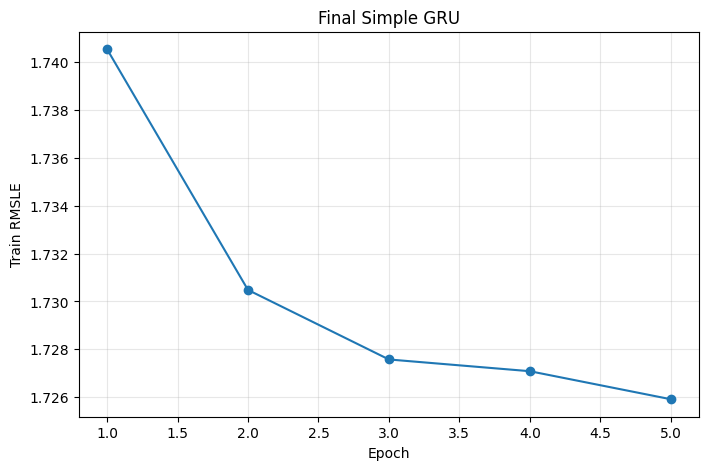

In [6]:
train_rmsle = np.sqrt(train_losses)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(train_rmsle) + 1),
    train_rmsle,
    marker='o',
)
plt.xlabel('Epoch')
plt.ylabel('Train RMSLE')
plt.title('Final Simple GRU')
plt.grid(alpha=0.3)
plt.show()

In [7]:
competition_data = pd.read_parquet(competition_file)

if 'target' not in competition_data.columns:
    competition_data['target'] = 0.0

user_ids = (
    competition_data['user_id']
    .drop_duplicates()
    .to_numpy()
)

competition_loader = create_dataloader_dataset(
    competition_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

predictions = []
model.eval()

with torch.no_grad():
    for features, target in tqdm(
        competition_loader,
        desc='Submission batches',
    ):
        features = features.to(device)
        prediction_log = model(features)
        prediction_log = torch.clamp(prediction_log, min=0)
        predictions.append(
            torch.expm1(prediction_log).cpu().numpy()
        )

predictions = np.concatenate(predictions)
assert len(user_ids) == len(predictions)

submission = pd.DataFrame({
    'user_id': user_ids,
    'predict': predictions,
})

assert submission['user_id'].is_unique
assert submission['predict'].notna().all()
assert (submission['predict'] >= 0).all()

submission_path = Path('/kaggle/working/submission_simple_gru.csv')
submission.to_csv(submission_path, index=False)

prediction_path = Path(
    '/kaggle/working/simple_gru_competition_predictions.csv'
)
pd.DataFrame({
    'user_id': user_ids,
    'gru_prediction': predictions,
    'gru_prediction_log': np.log1p(predictions),
}).to_csv(prediction_path, index=False)

print('Submission:', submission_path)
print('Предсказания для ансамбля:', prediction_path)
print('Строк:', len(submission))
submission.head()

Submission batches: 100%|██████████| 1954/1954 [00:31<00:00, 62.24it/s]


Submission: /kaggle/working/submission_simple_gru.csv
Предсказания для ансамбля: /kaggle/working/simple_gru_competition_predictions.csv
Строк: 250000


,user_id,predict
0,2,2.678731
1,7,70.067352
2,15,10.016391
3,18,140.568893
4,23,0.805347


In [8]:
model = model.to('cpu')
model_path = Path('/kaggle/working/final_simple_gru.pt')

torch.save(
    {
        'model_name': 'Simple GRU',
        'input_size': INPUT_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'epochs': EPOCHS,
        'state_dict': model.state_dict(),
        'train_rmsle': train_rmsle,
        'feature_columns': feature_columns,
    },
    model_path,
)

print('Модель сохранена:', model_path)

Модель сохранена: /kaggle/working/final_simple_gru.pt
